# Regime‑Adaptive Fill Probability Modeling for Limit Order Books

This notebook builds a complete research pipeline for estimating execution probabilities
using depth‑20 orderbook snapshots.

Models included:
- Probability surface P(fill | distance, volume)
- Queue position model
- Poisson order arrival model
- Deep learning fill predictor
- Regime detection
- Regime‑specific probability surfaces
- Regime‑optimized model weights
- Real‑time probability estimation

Assumes dataframe `df_market` with:
- snap_idx
- side ('Bid'/'Ask')
- price
- qty


# 1 Imports

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from scipy.optimize import minimize

sns.set_style('darkgrid')
import pyarrow as pa
import pyarrow.parquet as pq
import copy
import glob
import os
import warnings
warnings.simplefilter("ignore")
import matplotlib.pyplot as plt

In [3]:
def read_pq(date: str,full = False, instrument: str | None = None,  exc: str | None = None):
    # read all the parquet file downloaded
    root = f"C:/GIT/market_game/market_data/NIFTY_FUT/2026-{date}"

    all_files = glob.glob(
        "**/*.parquet",
        root_dir=root,
        recursive=True
    )

    df = pd.DataFrame()
    
    i = 1
    
    #club all the files into a single one
    for file_name in all_files:
        try:
            if instrument is None:
                _df = pd.read_parquet(os.path.join(root, file_name))
            else:
                _df = pd.read_parquet(os.path.join(root, file_name))
                _df = _df[_df['security_id'] == instrument]
        except:
            continue
        
        df = pd.concat([df, _df], axis= 0)
    
    '''
    compute the mid price and 
    normalize the price so that we are concerned of only the distance from centre
    '''
    if full:
        
        __ask = df[df["side"] == "Ask"].groupby("snap_idx")["price"].min()
        __bid = df[df["side"] == "Bid"].groupby("snap_idx")["price"].max()
        __mid = 0.5*(__ask + __bid)

        df = df.reset_index(drop = True)
        df["price_norm"] = df["price"] - df["snap_idx"].map(__mid)
        
        # considering only NIFTY future with lot = 65
        if exc == 'fno':
            df["qty_norm"] = df["qty"] / 65 
        else:
            df["qty_norm"] = df["qty"]  
        
        return df, __mid
    else:
        return df, None
        

In [4]:
full= True
df_market, mid_price = read_pq('02-27', full, '51714', 'fno')

# 2 Convert DataFrame to Snapshots

In [5]:
LEVELS = 20

def dataframe_to_snapshots(df):
    snapshots = []
    
    for snap, group in df.groupby('snap_idx'):
        bid = group[group.side=='Bid'].sort_values('price',ascending=False)
        ask = group[group.side=='Ask'].sort_values('price')
        
        snapshots.append({
            'bid_prices': bid.price.values[:LEVELS],
            'ask_prices': ask.price.values[:LEVELS],
            'bid_vol': bid.qty.values[:LEVELS],
            'ask_vol': ask.qty.values[:LEVELS]
        })
    
    return snapshots

# 3 Midprice Function

In [6]:
def get_mid_price(snap):
    return (snap['bid_prices'][0] + snap['ask_prices'][0]) / 2

# 4 Feature Engineering for Regime Detection

In [7]:
def regime_features(book):
    feats = []
    
    for snap in book:
        spread = snap['ask_prices'][0] - snap['bid_prices'][0]
        bid_vol = np.sum(snap['bid_vol'][:5])
        ask_vol = np.sum(snap['ask_vol'][:5])
        imbalance = (bid_vol - ask_vol)/(bid_vol + ask_vol + 1e-8)
        
        feats.append([spread,bid_vol,ask_vol,imbalance])
        
    return np.array(feats)

# 5 Regime Detection

In [8]:
N_REGIMES = 3

def train_regime_model(book):
    X = regime_features(book)
    model = KMeans(n_clusters=N_REGIMES, random_state=42)
    regimes = model.fit_predict(X)
    return model, regimes

# 6 Distance and Volume Buckets

In [9]:
DIST_BUCKETS = [0,1,2,3,4,6,8,12,16]
VOL_BUCKETS = [1,10,25,50,100,200,500]

def distance_from_mid(price, mid, tick=0.01):
    return abs(price-mid)/tick

def get_bucket(value, buckets):
    for i in range(len(buckets)-1):
        if buckets[i] <= value < buckets[i+1]:
            return i
    return len(buckets)-2

# 7 Build Regime‑Specific Probability Surfaces

In [10]:
def build_regime_surfaces(book, regimes, horizon=5):
    surfaces = {}
    
    for r in np.unique(regimes):
        counts = np.zeros((len(DIST_BUCKETS)-1,len(VOL_BUCKETS)-1))
        fills = np.zeros_like(counts)
        
        idx = np.where(regimes==r)[0]
        
        for t in idx:
            if t+horizon >= len(book):
                continue
                
            snap = book[t]
            future = book[t+horizon]
            mid = get_mid_price(snap)
            
            for level in range(20):
                price = snap['bid_prices'][level]
                vol = snap['bid_vol'][level]
                
                dist = distance_from_mid(price,mid)
                d_bin = get_bucket(dist,DIST_BUCKETS)
                v_bin = get_bucket(vol,VOL_BUCKETS)
                
                counts[d_bin,v_bin]+=1
                
                if future['ask_prices'][0] <= price:
                    fills[d_bin,v_bin]+=1
        
        surfaces[r] = fills/(counts+1e-8)
    
    return surfaces

# 8 Queue Model

In [11]:
def estimate_queue_position(snap, side='bid', level=0):
    if side=='bid':
        return snap['bid_vol'][level]
    return snap['ask_vol'][level]

def estimate_traded_volume(book,t,horizon=5):
    if t+horizon >= len(book):
        return 0
    mid_now = get_mid_price(book[t])
    mid_future = get_mid_price(book[t+horizon])
    return abs(mid_future-mid_now)*100

def compute_p_queue(book,t):
    snap = book[t]
    queue_pos = estimate_queue_position(snap)
    traded = estimate_traded_volume(book,t)
    if queue_pos<=0:
        return 1
    return min(traded/queue_pos,1)

# 9 Poisson Arrival Model

In [12]:
def estimate_lambda(book,window=200):
    arrivals=[]
    for t in range(1,window):
        m1 = get_mid_price(book[t-1])
        m2 = get_mid_price(book[t])
        arrivals.append(abs(m2-m1))
    return np.mean(arrivals)*10

def p_poisson(lam,horizon=5):
    return 1-np.exp(-lam*horizon)

# 10 Deep Learning Fill Predictor

In [13]:
def build_training_data(book,horizon=5):
    X=[]
    y=[]
    for t in range(len(book)-horizon):
        snap = book[t]
        mid = get_mid_price(snap)
        spread = snap['ask_prices'][0]-snap['bid_prices'][0]
        bid_vol = np.sum(snap['bid_vol'][:5])
        ask_vol = np.sum(snap['ask_vol'][:5])
        imbalance = (bid_vol-ask_vol)/(bid_vol+ask_vol+1e-8)
        
        X.append([mid,spread,bid_vol,ask_vol,imbalance])
        
        future_mid = get_mid_price(book[t+horizon])
        y.append(1 if future_mid>mid else 0)
    return np.array(X),np.array(y)

# 11 Train Deep Learning Model

In [14]:
def train_dl_model(book):
    X,y = build_training_data(book)
    model = MLPClassifier(hidden_layer_sizes=(64,32),max_iter=200)
    model.fit(X,y)
    return model

# 12 DL Fill Probability

In [15]:
def p_dl(model,snap):
    mid = get_mid_price(snap)
    spread = snap['ask_prices'][0]-snap['bid_prices'][0]
    bid_vol = np.sum(snap['bid_vol'][:5])
    ask_vol = np.sum(snap['ask_vol'][:5])
    imbalance = (bid_vol-ask_vol)/(bid_vol+ask_vol+1e-8)
    
    X = np.array([[mid,spread,bid_vol,ask_vol,imbalance]])
    return model.predict_proba(X)[0,1]

# 13 Query Regime Surface

In [16]:
def p_surface_regime(price,volume,mid,regime,surfaces):
    surface = surfaces[regime]
    dist = distance_from_mid(price,mid)
    d_bin = get_bucket(dist,DIST_BUCKETS)
    v_bin = get_bucket(volume,VOL_BUCKETS)
    return surface[d_bin,v_bin]

# 14 Online Probability Estimation

In [27]:
def run_probability_engine(book,regime_model,surfaces,dl_model,lam,weights,start=500):
    history=[]
    
    for t in range(start,len(book)):
        snap = book[t]
        mid = get_mid_price(snap)
        price = snap['bid_prices'][0]
        volume = snap['bid_vol'][0]
        
        regime = regime_model.predict([regime_features([snap])[0]])[0]
        
        ps = p_surface_regime(price,volume,mid,regime,surfaces)
        pq = compute_p_queue(book,t)
        pp = p_poisson(lam)
        p_dl_prob  = p_dl(dl_model,snap)
        
        w = weights[regime]
        
        p_final = w[0]*ps + w[1]*pq + w[2]*pp + w[3]*p_dl_prob
        
        history.append({
            'time':t,
            'p_surface':ps,
            'p_queue':pq,
            'p_poisson':pp,
            'p_dl':p_dl_prob ,
            'p_final':p_final
        })
    
    return pd.DataFrame(history)

# 15 Plot Analytics

In [18]:
def plot_probability_models(df_prob):
    plt.figure()
    plt.plot(df_prob.p_surface,label='Surface')
    plt.plot(df_prob.p_queue,label='Queue')
    plt.plot(df_prob.p_poisson,label='Poisson')
    plt.plot(df_prob.p_dl,label='Deep Learning')
    plt.legend()
    plt.title('Fill Probability Models')
    plt.show()

def plot_final_probability(df_prob):
    plt.figure()
    plt.plot(df_prob.p_final)
    plt.title('Final Fill Probability')
    plt.xlabel('Time')
    plt.ylabel('Probability')
    plt.show()

In [20]:
book = dataframe_to_snapshots(df_market)

regime_model, regimes = train_regime_model(book[:500])

surfaces = build_regime_surfaces(book[:500], regimes)

dl_model = train_dl_model(book[:500])

lam = estimate_lambda(book[:500])



In [21]:
weights = {
    0:[0.4,0.3,0.2,0.1],
    1:[0.3,0.4,0.2,0.1],
    2:[0.2,0.3,0.2,0.3]
}

In [28]:
df_prob = run_probability_engine(
    book,
    regime_model,
    surfaces,
    dl_model,
    lam,
    weights
)

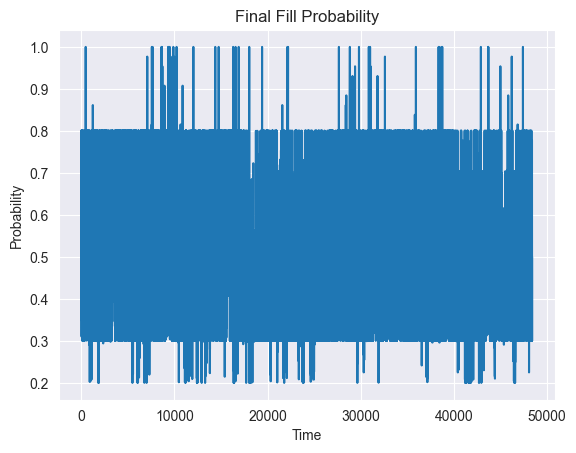

In [35]:
plot_final_probability(df_prob)

## Microstructure Features

In [37]:

def micro_features(snap):

    spread = snap["ask_prices"][0] - snap["bid_prices"][0]

    bid_vol = np.sum(snap["bid_vol"][:5])
    ask_vol = np.sum(snap["ask_vol"][:5])

    imbalance = (bid_vol - ask_vol)/(bid_vol + ask_vol + 1e-8)

    return spread, imbalance, bid_vol, ask_vol


## Buckets

In [38]:

DIST_BUCKETS = [0,1,2,3,4,6,8,12,16]
VOL_BUCKETS = [1,10,25,50,100,200,500]
IMB_BUCKETS = [-1,-0.5,-0.2,0,0.2,0.5,1]
SPR_BUCKETS = [0,0.01,0.02,0.05,0.1,0.5]

def bucket(val, buckets):

    for i in range(len(buckets)-1):

        if buckets[i] <= val < buckets[i+1]:
            return i

    return len(buckets)-2


## Build 4D Execution Surface

In [39]:

def build_execution_surface(book, horizon=5):

    dims = (
        len(DIST_BUCKETS)-1,
        len(VOL_BUCKETS)-1,
        len(IMB_BUCKETS)-1,
        len(SPR_BUCKETS)-1
    )

    counts = np.zeros(dims)
    fills = np.zeros(dims)

    for t in range(len(book)-horizon):

        snap = book[t]
        future = book[t+horizon]

        mid = get_mid_price(snap)

        spread, imbalance, bid_vol, ask_vol = micro_features(snap)

        imb_bin = bucket(imbalance, IMB_BUCKETS)
        spr_bin = bucket(spread, SPR_BUCKETS)

        for level in range(20):

            price = snap["bid_prices"][level]
            vol = snap["bid_vol"][level]

            dist = abs(price - mid)

            d_bin = bucket(dist, DIST_BUCKETS)
            v_bin = bucket(vol, VOL_BUCKETS)

            counts[d_bin,v_bin,imb_bin,spr_bin] += 1

            if future["ask_prices"][0] <= price:
                fills[d_bin,v_bin,imb_bin,spr_bin] += 1

    return fills/(counts+1e-8)


## Query Surface

In [40]:

def p_surface4d(price, volume, snap, surface):

    mid = get_mid_price(snap)

    spread, imbalance, _, _ = micro_features(snap)

    dist = abs(price-mid)

    d = bucket(dist, DIST_BUCKETS)
    v = bucket(volume, VOL_BUCKETS)
    i = bucket(imbalance, IMB_BUCKETS)
    s = bucket(spread, SPR_BUCKETS)

    return surface[d,v,i,s]
